In [ ]:
import os
import pandas as pd

os.chdir('/content/projet_ML')

# إضافة on_bad_lines='skip' باش يتجاوز الصفوف المشكوكة
df = pd.read_csv('delaney-processed.csv', on_bad_lines='skip')

os.makedirs('data/raw', exist_ok=True)
df.to_csv('data/raw/delaney.csv', index=False)

print(f'✅ Dataset loaded — Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

✅ Dataset loaded — Shape: (966, 10)
Columns: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


In [ ]:
import sys
sys.path.append('/content/projet_ML')

from src.features.molecular_descriptors import generate_features_df

print('⏳ Generating molecular descriptors...')
smiles_list = df['smiles'].tolist()
features_df = generate_features_df(smiles_list)

# إضافة الـ target
features_df['logS_exp'] = df['measured log solubility in mols per litre'].values[:len(features_df)]

print(f'✅ Features generated — Shape: {features_df.shape}')
features_df.head()

⏳ Generating molecular descriptors...
✅ Features generated — Shape: (966, 13)


,MW,LogP,TPSA,NumRotatableBonds,NumHDonors,NumHAcceptors,NumRings,NumAromaticRings,BertzCT,HallKierAlpha,LabuteASA,SMILES,logS_exp
0,457.432,-3.10802,202.32,7,7,12,3,1,759.662938,-1.73,182.935327,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,201.225,2.84032,42.24,2,1,2,2,2,459.484175,-2.03,87.724095,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,152.237,2.87800,17.07,4,0,1,0,0,171.311799,-0.85,68.806046,CC(C)=CCCC(C)=CC(=O),-2.06
3,278.354,6.29940,0.00,0,0,0,5,5,1071.547817,-2.86,128.158061,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,84.143,1.74810,0.00,0,0,1,1,1,60.124818,-0.30,35.071766,c1ccsc1,-1.33


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# فصل Features عن Target
X = features_df.drop(['SMILES', 'logS_exp'], axis=1)
y = features_df['logS_exp']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تقسيم 80% train — 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'✅ Train: {X_train.shape[0]} samples')
print(f'✅ Test:  {X_test.shape[0]} samples')

✅ Train: 772 samples
✅ Test:  194 samples


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print('⏳ Evaluating models...\n')
cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-cv_scores).mean()
    std  = np.sqrt(-cv_scores).std()
    cv_results[name] = rmse
    print(f'{name:25s}: RMSE = {rmse:.4f} (±{std:.4f})')

⏳ Evaluating models...

Ridge                    : RMSE = 0.9541 (±0.0734)
Lasso                    : RMSE = 1.5294 (±0.1260)
Random Forest            : RMSE = 0.7083 (±0.0484)
Gradient Boosting        : RMSE = 0.7150 (±0.0557)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

print('⏳ Tuning hyperparameters...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_
print(f'\n✅ Best params: {grid_search.best_params_}')
print(f'✅ Best RMSE:   {np.sqrt(-grid_search.best_score_):.4f}')

⏳ Tuning hyperparameters...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best RMSE:   0.7095


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('📊 Final Model Performance:')
print(f'   RMSE : {rmse:.4f}')
print(f'   MAE  : {mae:.4f}')
print(f'   R²   : {r2:.4f}')

📊 Final Model Performance:
   RMSE : 0.7597
   MAE  : 0.5432
   R²   : 0.8417


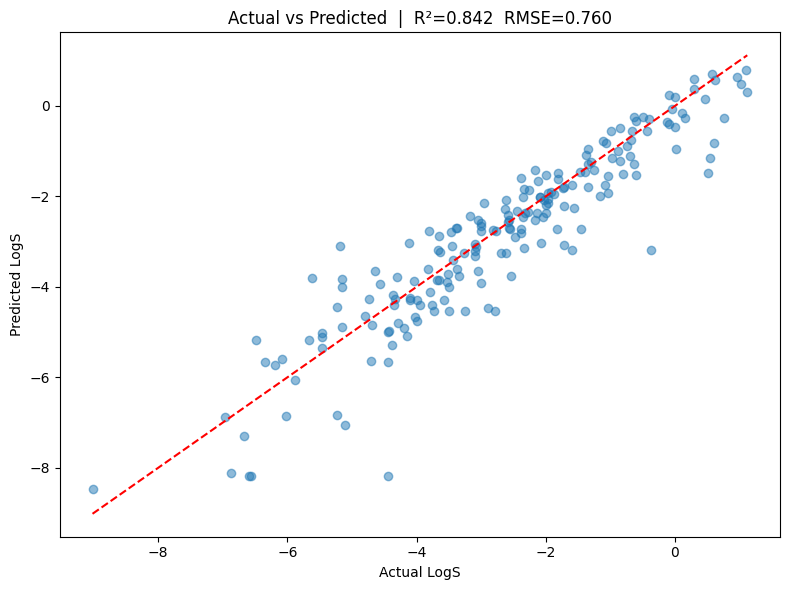

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual LogS')
plt.ylabel('Predicted LogS')
plt.title(f'Actual vs Predicted  |  R²={r2:.3f}  RMSE={rmse:.3f}')
plt.tight_layout()
plt.show()

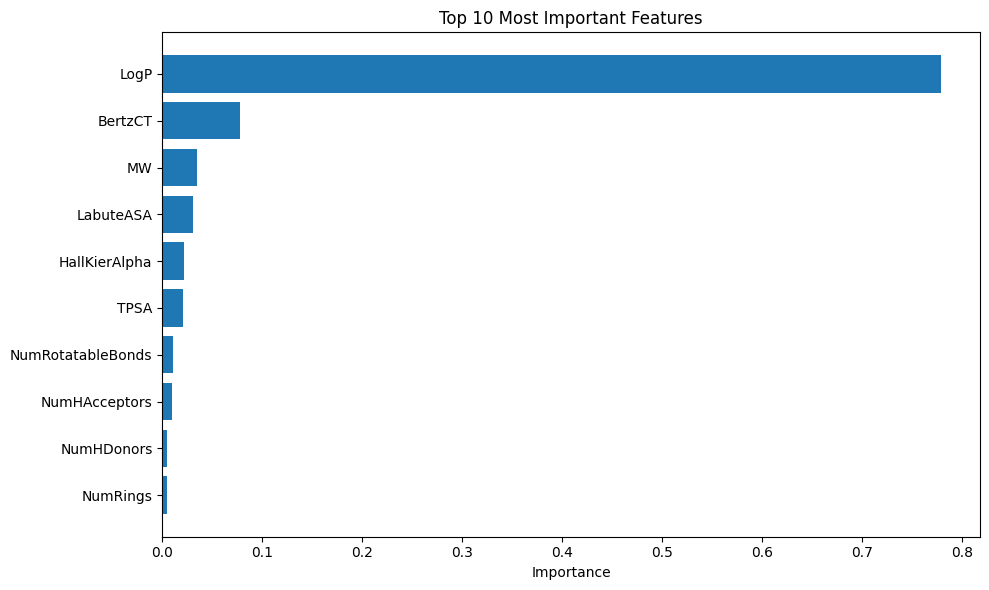

          Feature  Importance
             LogP    0.778712
          BertzCT    0.077625
               MW    0.034514
        LabuteASA    0.031250
    HallKierAlpha    0.022196
             TPSA    0.020581
NumRotatableBonds    0.011262
    NumHAcceptors    0.010110
       NumHDonors    0.004971
         NumRings    0.004779


In [ ]:
import pandas as pd

feature_names = features_df.drop(['SMILES', 'logS_exp'], axis=1).columns

importances = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][:10][::-1],
         importances['Importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

print(importances.head(10).to_string(index=False))

In [ ]:
from src.models.predict_model import predict_solubility
import pandas as pd

new_smiles = [
    'CC(=O)OC1=CC=CC=C1C(=O)O',
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
    'CCC1(CC)C(=O)NC(=O)N(C)C1=O'
]
names = ['Aspirin', 'Caffeine', 'Ibuprofen', 'Phenobarbital']

predictions = predict_solubility(rf_model, new_smiles, scaler=scaler)
predictions['Compound'] = names

print('🔮 Predictions:')
print(predictions[['Compound', 'Predicted_Solubility']].to_string(index=False))

🔮 Predictions:
     Compound  Predicted_Solubility
      Aspirin             -2.120270
     Caffeine             -1.164211
    Ibuprofen             -3.524580
Phenobarbital             -2.082373


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
import pickle, os

os.makedirs('/content/projet_ML/models', exist_ok=True)

with open('/content/projet_ML/models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('/content/projet_ML/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Model and scaler saved!')

✅ Model and scaler saved!


In [ ]:
from google.colab import files

files.download('/content/projet_ML/models/random_forest_model.pkl')
files.download('/content/projet_ML/models/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# حمّل الـ notebook
files.download('/content/projet_ML/notebooks/02_model_development_fixed.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# أولاً حفظ الـ notebook مع outputs
import nbformat

# تحميل الـ notebook
with open('/content/projet_ML/notebooks/02_model_development_fixed.ipynb', 'r') as f:
    nb = nbformat.read(f, as_version=4)

# حفظه مع outputs
with open('/content/projet_ML/notebooks/02_model_development_final.ipynb', 'w') as f:
    nbformat.write(nb, f)

# تحميله
from google.colab import files
files.download('/content/projet_ML/notebooks/02_model_development_final.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>